# Adversarial Presentation Agent — Statistical Analysis

**Design:** 2×2 mixed ANOVA
- Between-subjects: `condition` (memory / no-memory)
- Within-subjects: `session` (1, 2)
- DVs: composite performance score (0–100) and perceived preparedness score (3–15)

**Data sources:**
- `results/*/summary.csv` — one row per participant-session (exported by export.py)
- `survey.csv` — flat CSV with `participant_id`, `session`, `preparedness_score`

**Conversion to Jupyter:** `jupytext --to notebook analysis_nb.py`

pip install pingouin scipy pandas numpy matplotlib seaborn jupytext

## Section 0: Imports & Configuration

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Paths (edit as needed) ---
RESULTS_DIR = Path("results")                  # directory containing timestamped run subdirs
SURVEY_CSV = Path("survey.csv")                # flat CSV: participant_id, session, preparedness_score
PARTICIPANTS_CSV = Path("analysis/participants.csv")  # directory→participant_id mapping

# --- Study constants ---
ALPHA = 0.05
N_PARTICIPANTS = 30
N_SESSIONS = 2
N_PER_CONDITION = 15
N_COMPARISONS = N_SESSIONS          # Bonferroni denominator for post-hoc t-tests

ALPHA_BONFERRONI = ALPHA / N_COMPARISONS

CONDITION_MAP = {
    "hybrid": "hybrid-memory",
    "document_only": "non-hybrid-memory",
}

sns.set_theme(style="whitegrid", palette="Set2")

## Section 1: Data Loading & Merging

In [2]:
def load_summary_csvs(results_dir: Path, participants_csv: Path) -> pd.DataFrame:
    """Glob all summary.csv files, assign participant_id and session from participants.csv."""
    participants = pd.read_csv(participants_csv)

    # Build lookup: directory name → (participant_id, session_number)
    dir_to_pid: dict[str, tuple[str, int]] = {}
    for _, row in participants.iterrows():
        dir_to_pid[row["session_dir_1"]] = (row["participant_id"], 1)
        dir_to_pid[row["session_dir_2"]] = (row["participant_id"], 2)

    paths = sorted(results_dir.glob("*/summary.csv"))
    if not paths:
        raise FileNotFoundError(f"No summary.csv files found under {results_dir.resolve()}")

    frames = []
    skipped = []
    for p in paths:
        dirname = p.parent.name
        if dirname not in dir_to_pid:
            skipped.append(dirname)
            continue
        pid, sess = dir_to_pid[dirname]
        df_tmp = pd.read_csv(p)
        df_tmp["participant_id"] = pid
        df_tmp["session"] = sess
        frames.append(df_tmp)

    if skipped:
        print(f"  Skipped {len(skipped)} directory(s) not in participants.csv: {skipped[:5]}")

    df = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(frames)} summary CSV(s) → {len(df)} rows")
    return df


def validate_data(df: pd.DataFrame, label: str = "merged") -> None:
    """Print warnings for any data quality issues."""
    issues = []

    n_participants = df["participant_id"].nunique()
    if n_participants != N_PARTICIPANTS:
        issues.append(
            f"Expected {N_PARTICIPANTS} unique participants, found {n_participants}"
        )

    session_counts = df.groupby("participant_id")["session"].nunique()
    bad = session_counts[session_counts != N_SESSIONS]
    if not bad.empty:
        issues.append(
            f"{len(bad)} participant(s) don't have exactly {N_SESSIONS} sessions: "
            + ", ".join(bad.index.astype(str))
        )

    cond_counts = df.drop_duplicates("participant_id")["condition"].value_counts()
    for cond, expected in [("hybrid-memory", N_PER_CONDITION), ("non-hybrid-memory", N_PER_CONDITION)]:
        actual = cond_counts.get(cond, 0)
        if actual != expected:
            issues.append(f"Expected {expected} participants in '{cond}', found {actual}")

    if "preparedness_score" in df.columns:
        bad_conf = df[~df["preparedness_score"].between(1, 7)]
        if not bad_conf.empty:
            issues.append(
                f"{len(bad_conf)} preparedness_score value(s) outside [1, 7]"
            )

    if issues:
        print(f"\n[DATA WARNINGS — {label}]")
        for issue in issues:
            print(f"  ⚠  {issue}")
    else:
        print(f"[{label}] All validation checks passed.")


# Load performance + contradiction data
perf_df = load_summary_csvs(RESULTS_DIR, PARTICIPANTS_CSV)
perf_df["condition"] = perf_df["memory_type"].map(CONDITION_MAP)

# Load preparedness survey data
if not SURVEY_CSV.exists():
    raise FileNotFoundError(
        f"Survey CSV not found at {SURVEY_CSV.resolve()}. "
        "Expected columns: participant_id, session, preparedness_score"
    )
survey_df = pd.read_csv(SURVEY_CSV)
survey_df["session"] = survey_df["session"].astype(int)
print(f"Loaded survey CSV → {len(survey_df)} rows")

# Merge: keep overall_score, contradictions_detected, and preparedness_score
perf_cols = ["participant_id", "session", "condition",
             "overall_score", "contradictions_detected"]
df = perf_df[perf_cols].merge(
    survey_df[["participant_id", "session", "preparedness_score"]],
    on=["participant_id", "session"],
    how="inner",
    validate="1:1",
)
df["session"] = df["session"].astype(int)
print(f"Merged dataset: {len(df)} rows, {df['participant_id'].nunique()} participants")

validate_data(df, label="merged dataset")

Loaded 60 summary CSV(s) → 60 rows
Loaded survey CSV → 60 rows
Merged dataset: 60 rows, 30 participants
[merged dataset] All validation checks passed.


## Section 2: Descriptive Statistics

In [3]:
DVS = {
    "overall_score": "Composite Performance Score (0–100)",
    "preparedness_score": "Perceived Preparedness Score (1–7)",
    "contradictions_detected": "Contradictions Detected (count)",
}

for col, label in DVS.items():
    print(f"\n{'='*60}")
    print(f"Descriptive statistics — {label}")
    print("="*60)
    desc = (
        df.groupby(["condition", "session"])[col]
        .agg(n="count", mean="mean", sd="std", se=lambda x: x.std() / np.sqrt(len(x)),
             min="min", max="max")
        .round(3)
    )
    print(desc.to_string())


Descriptive statistics — Composite Performance Score (0–100)
                            n    mean      sd     se   min   max
condition         session                                       
hybrid-memory     1        15  55.247  11.354  2.932  26.4  69.3
                  2        15  61.820   8.918  2.303  49.6  75.1
non-hybrid-memory 1        15  52.647  13.026  3.363  25.9  64.4
                  2        15  57.753  12.268  3.168  29.2  74.0

Descriptive statistics — Perceived Preparedness Score (1–7)
                            n   mean     sd     se    min    max
condition         session                                       
hybrid-memory     1        15  2.867  1.457  0.376  1.000  5.000
                  2        15  5.764  0.682  0.176  4.769  7.000
non-hybrid-memory 1        15  3.267  1.486  0.384  1.000  5.000
                  2        15  5.395  0.628  0.162  4.462  6.462

Descriptive statistics — Contradictions Detected (count)
                            n   mean   

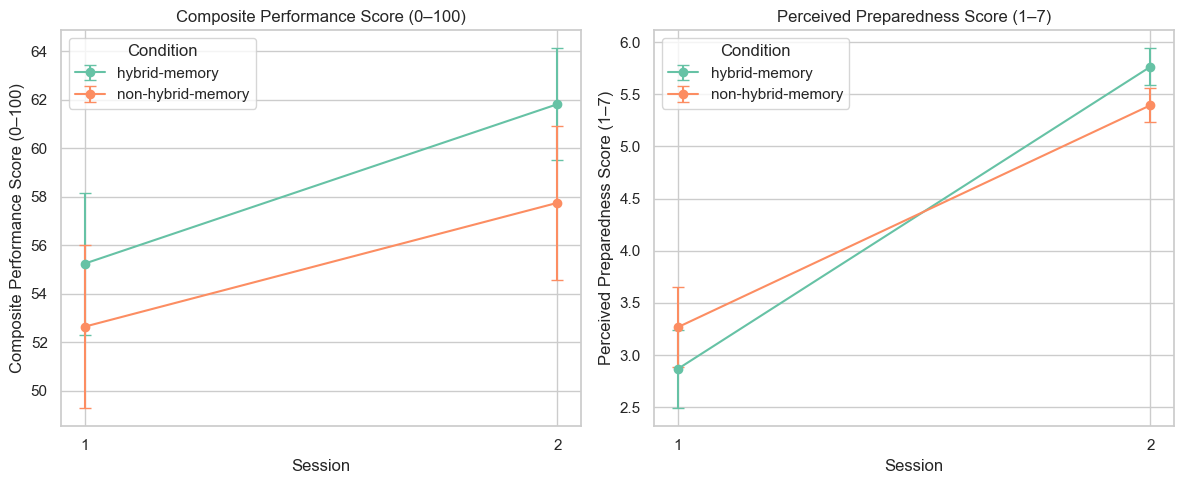

In [4]:
# Line plots: Composite Performance Score and Perceived Preparedness Score
line_dvs = {k: v for k, v in DVS.items() if k != "contradictions_detected"}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (col, label) in zip(axes, line_dvs.items()):
    summary = (
        df.groupby(["session", "condition"])[col]
        .agg(mean="mean", se=lambda x: x.std() / np.sqrt(len(x)))
        .reset_index()
    )
    for cond, grp in summary.groupby("condition"):
        ax.errorbar(
            grp["session"], grp["mean"], yerr=grp["se"],
            marker="o", capsize=4, label=cond,
        )
    ax.set_xticks([1, 2])
    ax.set_xlabel("Session")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(title="Condition")

plt.tight_layout()
plt.savefig("fig_line_plots.png", dpi=150)
plt.show()

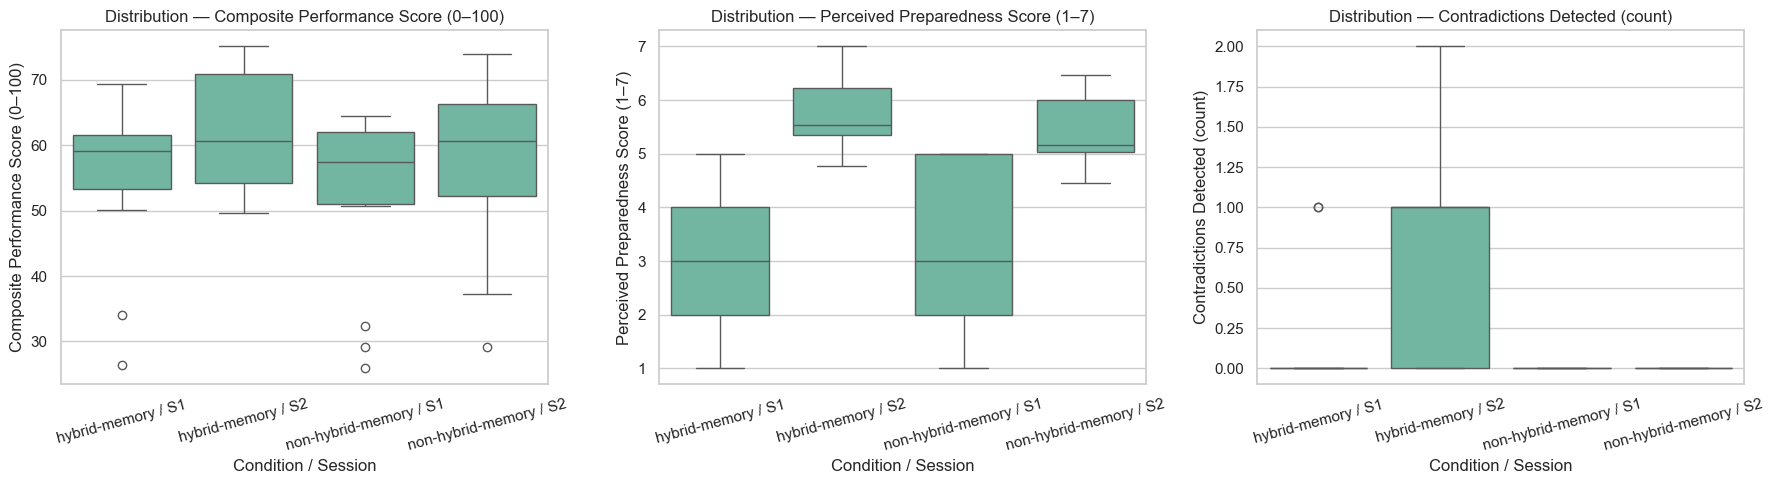

In [5]:
# Box plots: all three DVs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, DVS.items()):
    plot_df = df.copy()
    plot_df["group"] = plot_df["condition"] + " / S" + plot_df["session"].astype(str)
    order = ["hybrid-memory / S1", "hybrid-memory / S2", "non-hybrid-memory / S1", "non-hybrid-memory / S2"]
    sns.boxplot(data=plot_df, x="group", y=col, order=order, ax=ax)
    ax.set_xlabel("Condition / Session")
    ax.set_ylabel(label)
    ax.set_title(f"Distribution — {label}")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("fig_box_plots.png", dpi=150)
plt.show()

## Section 3: Assumption Checks

In [6]:
def check_normality(df: pd.DataFrame, col: str, label: str) -> bool:
    """Shapiro-Wilk on each condition×session cell. Returns True if all cells pass."""
    print(f"\nShapiro-Wilk normality test — {label}")
    print(f"{'Cell':<25} {'W':>8} {'p':>10} {'Result'}")
    print("-" * 55)
    all_ok = True
    for (cond, sess), grp in df.groupby(["condition", "session"]):
        vals = grp[col].dropna().values
        if len(vals) < 3:
            print(f"  {cond} / S{sess:<18} {'—':>8} {'—':>10}  SKIP (n<3)")
            continue
        W, p = stats.shapiro(vals)
        ok = p > ALPHA
        if not ok:
            all_ok = False
        flag = "PASS" if ok else "FAIL ⚠"
        print(f"  {cond} / S{sess:<18} {W:>8.4f} {p:>10.4f}  {flag}")
    return all_ok


def check_levene(df: pd.DataFrame, col: str, label: str) -> bool:
    """Levene's test at each session. Returns True if all pass."""
    print(f"\nLevene's homogeneity of variance test — {label}")
    print(f"{'Session':<12} {'stat':>8} {'p':>10} {'Result'}")
    print("-" * 40)
    all_ok = True
    for sess in sorted(df["session"].unique()):
        groups = [
            grp[col].dropna().values
            for _, grp in df[df["session"] == sess].groupby("condition")
        ]
        stat, p = stats.levene(*groups)
        ok = p > ALPHA
        if not ok:
            all_ok = False
        flag = "PASS" if ok else "FAIL ⚠"
        print(f"  Session {sess:<7} {stat:>8.4f} {p:>10.4f}  {flag}")
    return all_ok


normality_ok = {}
levene_ok = {}

for col, label in DVS.items():
    normality_ok[col] = check_normality(df, col, label)
    levene_ok[col] = check_levene(df, col, label)

print("\n" + "="*60)
print("Sphericity")
print("="*60)
print(
    "Sphericity assumption is NOT applicable: the within-subjects factor\n"
    "(session) has only 2 levels. Greenhouse-Geisser correction is not needed.\n"
    "Note: the pre-registered design specified 3 sessions; only 2 were completed."
)


Shapiro-Wilk normality test — Composite Performance Score (0–100)
Cell                             W          p Result
-------------------------------------------------------
  hybrid-memory / S1                    0.8273     0.0084  FAIL ⚠
  hybrid-memory / S2                    0.9100     0.1355  PASS
  non-hybrid-memory / S1                    0.7977     0.0034  FAIL ⚠
  non-hybrid-memory / S2                    0.9214     0.2020  PASS

Levene's homogeneity of variance test — Composite Performance Score (0–100)
Session          stat          p Result
----------------------------------------
  Session 1         0.2704     0.6072  PASS
  Session 2         0.3113     0.5813  PASS

Shapiro-Wilk normality test — Perceived Preparedness Score (1–7)
Cell                             W          p Result
-------------------------------------------------------
  hybrid-memory / S1                    0.8947     0.0790  PASS
  hybrid-memory / S2                    0.9540     0.5899  PASS
  non-h

/usr/local/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


## Section 4: Analysis — Composite Performance Score

In [7]:
def cohen_d(x: np.ndarray, y: np.ndarray) -> float:
    """Pooled-SD Cohen's d."""
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx - 1) * x.std(ddof=1)**2 + (ny - 1) * y.std(ddof=1)**2) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_sd if pooled_sd > 0 else np.nan


def run_mixed_anova(df: pd.DataFrame, col: str, label: str) -> list:
    """Run mixed ANOVA (or non-parametric fallback) and return result rows."""
    print(f"\n{'='*60}")
    print(f"Mixed ANOVA — {label}")
    print("="*60)

    results = []

    if normality_ok[col]:
        aov = pg.mixed_anova(
            data=df, dv=col, within="session", between="condition", subject="participant_id"
        )
        print(aov[["Source", "F", "DF1", "DF2", "p_unc", "np2"]].to_string(index=False))

        for _, row in aov.iterrows():
            source = row["Source"]
            if source == "Intercept":
                continue
            sig = "Yes" if row["p_unc"] < ALPHA else "No"
            print(
                f"\n  [{source}] F({int(row['DF1'])},{int(row['DF2'])}) = {row['F']:.3f}, "
                f"p = {row['p_unc']:.4f}, η²_p = {row['np2']:.3f} → Significant: {sig}"
            )
            results.append({
                "DV": label, "Effect": source,
                "F": round(row["F"], 3), "df": f"{int(row['DF1'])},{int(row['DF2'])}",
                "p": round(row["p_unc"], 4), "eta_p2": round(row["np2"], 3),
                "Significant": sig, "Test": "Mixed ANOVA",
            })

        # Post-hoc if interaction significant
        interaction_row = aov[aov["Source"] == "Interaction"]
        if not interaction_row.empty and interaction_row.iloc[0]["p_unc"] < ALPHA:
            print(f"\n  Interaction is significant → post-hoc t-tests at each session")
            print(f"  Bonferroni α = {ALPHA}/{N_COMPARISONS} = {ALPHA_BONFERRONI:.4f}")
            for sess in sorted(df["session"].unique()):
                sess_df = df[df["session"] == sess]
                mem = sess_df[sess_df["condition"] == "hybrid-memory"][col].dropna().values
                nomem = sess_df[sess_df["condition"] == "non-hybrid-memory"][col].dropna().values
                t, p_unc = stats.ttest_ind(mem, nomem)
                p_bonf = min(p_unc * N_COMPARISONS, 1.0)
                d = cohen_d(mem, nomem)
                sig = "Yes" if p_bonf < ALPHA else "No"
                print(
                    f"    Session {sess}: t = {t:.3f}, p = {p_unc:.4f}, "
                    f"p_bonf = {p_bonf:.4f}, d = {d:.3f} → Significant: {sig}"
                )
                results.append({
                    "DV": label, "Effect": f"Post-hoc Session {sess}",
                    "F": np.nan, "df": f"{len(mem)+len(nomem)-2}",
                    "p": round(p_bonf, 4), "eta_p2": np.nan,
                    "d": round(d, 3), "Significant": sig, "Test": "t-test (Bonferroni)",
                })
        else:
            print("\n  Interaction not significant — no post-hoc tests required.")

    else:
        print(
            f"\n  Normality assumption failed for {label}. "
            "Using non-parametric alternatives."
        )
        print(
            "  Note: Friedman test applies for ≥3 within-subjects levels; "
            "Wilcoxon signed-rank is used here (2 sessions)."
        )

        # Between-group: Mann-Whitney U at each session
        print("\n  Mann-Whitney U (between conditions, per session):")
        for sess in sorted(df["session"].unique()):
            sess_df = df[df["session"] == sess]
            mem = sess_df[sess_df["condition"] == "hybrid-memory"][col].dropna().values
            nomem = sess_df[sess_df["condition"] == "non-hybrid-memory"][col].dropna().values
            U, p = stats.mannwhitneyu(mem, nomem, alternative="two-sided")
            sig = "Yes" if p < ALPHA else "No"
            print(f"    Session {sess}: U = {U:.1f}, p = {p:.4f} → Significant: {sig}")
            results.append({
                "DV": label, "Effect": f"Between (Session {sess})",
                "F": np.nan, "df": np.nan, "p": round(p, 4), "eta_p2": np.nan,
                "Significant": sig, "Test": "Mann-Whitney U",
            })

        # Within-group: Wilcoxon signed-rank per condition
        print("\n  Wilcoxon signed-rank (within condition across sessions):")
        for cond in ["hybrid-memory", "non-hybrid-memory"]:
            cond_df = df[df["condition"] == cond].sort_values(["participant_id", "session"])
            s1 = cond_df[cond_df["session"] == 1].set_index("participant_id")[col]
            s2 = cond_df[cond_df["session"] == 2].set_index("participant_id")[col]
            common = s1.index.intersection(s2.index)
            diffs = s2[common].values - s1[common].values
            if np.all(diffs == 0):
                print(f"    {cond}: all differences are zero — Wilcoxon not applicable (p = 1.0)")
                results.append({
                    "DV": label, "Effect": f"Within '{cond}'",
                    "F": np.nan, "df": np.nan, "p": 1.0, "eta_p2": np.nan,
                    "Significant": "No", "Test": "Wilcoxon signed-rank",
                })
                continue
            stat, p = stats.wilcoxon(s1[common].values, s2[common].values)
            sig = "Yes" if p < ALPHA else "No"
            print(f"    {cond}: W = {stat:.1f}, p = {p:.4f} → Significant: {sig}")
            results.append({
                "DV": label, "Effect": f"Within '{cond}'",
                "F": np.nan, "df": np.nan, "p": round(p, 4), "eta_p2": np.nan,
                "Significant": sig, "Test": "Wilcoxon signed-rank",
            })

    return results


perf_results = run_mixed_anova(df, "overall_score", DVS["overall_score"])


Mixed ANOVA — Composite Performance Score (0–100)

  Normality assumption failed for Composite Performance Score (0–100). Using non-parametric alternatives.
  Note: Friedman test applies for ≥3 within-subjects levels; Wilcoxon signed-rank is used here (2 sessions).

  Mann-Whitney U (between conditions, per session):
    Session 1: U = 122.0, p = 0.7088 → Significant: No
    Session 2: U = 127.0, p = 0.5610 → Significant: No

  Wilcoxon signed-rank (within condition across sessions):
    hybrid-memory: W = 29.0, p = 0.0833 → Significant: No
    non-hybrid-memory: W = 37.0, p = 0.2078 → Significant: No


## Section 4.5: H2 — Contradictions Detected

**H2** predicts that memory-enabled participants produce fewer contradictions across
sessions. `contradictions_detected` is the total number of contradictions flagged by
the agent per session.

Note: this variable is zero-inflated (median = 0, only ~17% of sessions have any
contradiction), so the non-parametric path is expected.

In [8]:
contra_results = run_mixed_anova(df, "contradictions_detected", DVS["contradictions_detected"])


Mixed ANOVA — Contradictions Detected (count)

  Normality assumption failed for Contradictions Detected (count). Using non-parametric alternatives.
  Note: Friedman test applies for ≥3 within-subjects levels; Wilcoxon signed-rank is used here (2 sessions).

  Mann-Whitney U (between conditions, per session):
    Session 1: U = 127.5, p = 0.1641 → Significant: No
    Session 2: U = 172.5, p = 0.0015 → Significant: Yes

  Wilcoxon signed-rank (within condition across sessions):
    hybrid-memory: W = 3.0, p = 0.0304 → Significant: Yes
    non-hybrid-memory: all differences are zero — Wilcoxon not applicable (p = 1.0)


## Section 5: Analysis — Perceived Preparedness Score

In [9]:
conf_results = run_mixed_anova(df, "preparedness_score", DVS["preparedness_score"])


Mixed ANOVA — Perceived Preparedness Score (1–7)

  Normality assumption failed for Perceived Preparedness Score (1–7). Using non-parametric alternatives.
  Note: Friedman test applies for ≥3 within-subjects levels; Wilcoxon signed-rank is used here (2 sessions).

  Mann-Whitney U (between conditions, per session):
    Session 1: U = 94.5, p = 0.4567 → Significant: No
    Session 2: U = 149.5, p = 0.1293 → Significant: No

  Wilcoxon signed-rank (within condition across sessions):
    hybrid-memory: W = 1.0, p = 0.0008 → Significant: Yes
    non-hybrid-memory: W = 3.0, p = 0.0019 → Significant: Yes


## Section 6: Results Summary Table


Spearman Correlation — Agent Perception vs. Performance (Session 2)
  N = 30
  ρ = 0.444,  p = 0.0141  →  Significant: Yes


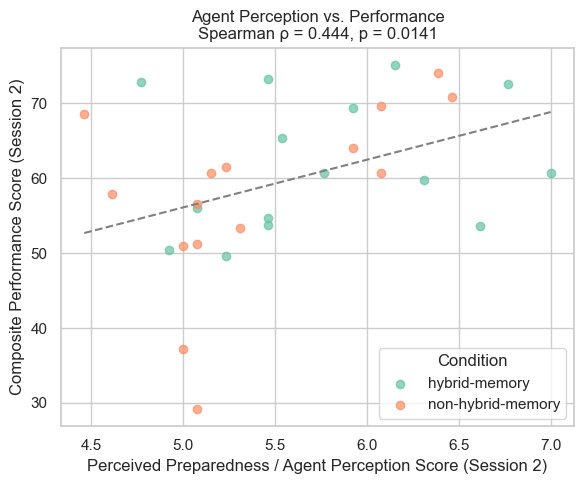

In [10]:
s2 = df[df["session"] == 2][["participant_id", "condition",
                               "preparedness_score", "overall_score"]].dropna()

rho, p_corr = stats.spearmanr(s2["preparedness_score"], s2["overall_score"])
sig_corr = "Yes" if p_corr < ALPHA else "No"

print(f"\n{'='*60}")
print("Spearman Correlation — Agent Perception vs. Performance (Session 2)")
print("="*60)
print(f"  N = {len(s2)}")
print(f"  ρ = {rho:.3f},  p = {p_corr:.4f}  →  Significant: {sig_corr}")

corr_results = [{
    "DV": "Perception × Performance (Session 2)",
    "Effect": "Spearman ρ",
    "Test": "Spearman correlation",
    "df": len(s2) - 2,
    "F": np.nan,
    "p": round(p_corr, 4),
    "eta_p2": np.nan,
    "rho": round(rho, 3),
    "Significant": sig_corr,
}]

# Scatter plot with regression line
fig, ax = plt.subplots(figsize=(6, 5))
palette = sns.color_palette("Set2", 2)
cond_colors = {"hybrid-memory": palette[0], "non-hybrid-memory": palette[1]}
for cond, grp in s2.groupby("condition"):
    ax.scatter(grp["preparedness_score"], grp["overall_score"],
               label=cond, color=cond_colors[cond], alpha=0.7)
# Overall regression line
m, b = np.polyfit(s2["preparedness_score"], s2["overall_score"], 1)
x_range = np.linspace(s2["preparedness_score"].min(), s2["preparedness_score"].max(), 100)
ax.plot(x_range, m * x_range + b, color="gray", linestyle="--", linewidth=1.5)
ax.set_xlabel("Perceived Preparedness / Agent Perception Score (Session 2)")
ax.set_ylabel("Composite Performance Score (Session 2)")
ax.set_title(f"Agent Perception vs. Performance\nSpearman ρ = {rho:.3f}, p = {p_corr:.4f}")
ax.legend(title="Condition")
plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=150)
plt.show()

## Section 7: Results Summary Table

In [11]:
all_results = perf_results + contra_results + conf_results + corr_results
summary_table = pd.DataFrame(all_results)

# Reorder columns sensibly
col_order = ["DV", "Effect", "Test", "df", "F", "p", "eta_p2", "rho", "d", "Significant"]
col_order = [c for c in col_order if c in summary_table.columns]
summary_table = summary_table[col_order]

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(summary_table.fillna("—").to_string(index=False))

# Save to CSV for reporting
summary_table.to_csv("results_summary.csv", index=False)
print("\nResults saved to results_summary.csv")


RESULTS SUMMARY
                                  DV                     Effect                 Test    df F      p eta_p2    rho Significant
 Composite Performance Score (0–100)        Between (Session 1)       Mann-Whitney U     — — 0.7088      —      —          No
 Composite Performance Score (0–100)        Between (Session 2)       Mann-Whitney U     — — 0.5610      —      —          No
 Composite Performance Score (0–100)     Within 'hybrid-memory' Wilcoxon signed-rank     — — 0.0833      —      —          No
 Composite Performance Score (0–100) Within 'non-hybrid-memory' Wilcoxon signed-rank     — — 0.2078      —      —          No
     Contradictions Detected (count)        Between (Session 1)       Mann-Whitney U     — — 0.1641      —      —          No
     Contradictions Detected (count)        Between (Session 2)       Mann-Whitney U     — — 0.0015      —      —         Yes
     Contradictions Detected (count)     Within 'hybrid-memory' Wilcoxon signed-rank     — — 0.0304  